In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs, make_moons
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

from sklearn.neighbors import kneighbors_graph
from scipy.sparse.linalg import eigsh

%matplotlib inline

## 1.1 Fondements théoriques du clustering

Qu'est-ce que le clustering ?
---------------------------
Le clustering (ou partitionnement) est une méthode d'apprentissage non supervisé qui consiste à regrouper des 
données similaires en sous-ensembles appelés clusters. Contrairement à l'apprentissage supervisé, nous n'avons 
pas d'étiquettes prédéfinies : l'algorithme doit découvrir la structure naturelle des données.

Objectifs du clustering :
1. Découvrir des groupes naturels dans les données
2. Identifier des patterns cachés
3. Simplifier la représentation des données
4. Détecter des anomalies

Applications courantes :
- Segmentation client
- Analyse d'images
- Recommandation de contenu
- Détection d'anomalies
- Analyse de documents


## Concepts Clés en Clustering

---

### 1. **Similarité : Comment mesurer la ressemblance entre deux points ?**

La similarité quantifie à quel point deux points (ou objets) sont proches ou semblables dans l'espace des données.

#### Moyens courants de mesurer la similarité :
- **Similitude cosinus** : Utilisée pour des données en haute dimension, particulièrement dans le traitement du langage naturel (e.g., documents ou vecteurs de mots).  
  Formule :  
  $$
  \text{Similitude Cosinus} = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\| \|\vec{B}\|}
  $$

- **Similitude de Jaccard** : Adaptée pour des ensembles ou des vecteurs binaires (présence/absence).  
  Formule :  
  $$
  \text{Jaccard}(A, B) = \frac{|A \cap B|}{|A \cup B|}
  $$

#### Applications :
- **Similitude cosinus** : Clustering de documents.
- **Similitude de Jaccard** : Analyse de données transactionnelles ou catégoriques.

---

### 2. **Distance : Quelle métrique utiliser ?**

La distance est une mesure de dissimilarité entre deux points. Le choix de la métrique dépend de la nature des données.

#### Métriques courantes :
1. **Distance euclidienne** : Convient pour des données continues.  
   Formule :  
   $$
   \text{Euclidienne}(A, B) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}
   $$

2. **Distance de Manhattan** : Plus robuste pour des données contenant des outliers.  
   Formule :  
   $$
   \text{Manhattan}(A, B) = \sum_{i=1}^{n} |A_i - B_i|
   $$

3. **Distance de Minkowski** : Une généralisation des distances euclidienne et Manhattan.  
   Formule :  
   $$
   \text{Minkowski}(A, B) = \left( \sum_{i=1}^{n} |A_i - B_i|^p \right)^{1/p}
   $$

4. **Distance Mahalanobis** : Utilisée pour des données corrélées ou non normalisées.  
   Formule :  
   $$
   \text{Mahalanobis}(A, B) = \sqrt{(A-B)^T \Sigma^{-1} (A-B)}
   $$  
   où \($ \Sigma $\) est la matrice de covariance.

#### Recommandations :
- Pour des données continues sans corrélation : **Euclidienne**.
- Pour des données catégoriques : **Hamming**.
- Pour des données corrélées ou ayant des dimensions hétérogènes : **Mahalanobis**.

---

### 3. **Densité : Comment définir un groupe "dense" de points ?**

La densité est une propriété clé dans les algorithmes comme **DBSCAN** ou **OPTICS**. Elle détermine si un groupe de points forme un cluster.

#### Critères courants pour définir la densité :
1. **Nombre de voisins** : Un point appartient à un cluster si suffisamment d'autres points se trouvent dans un rayon donné (\($ \varepsilon $\)).
2. **Densité locale** : Mesurée en fonction du nombre de points par unité de volume autour d'un point.

#### Exemple avec DBSCAN :
- Les clusters sont formés par des "noyaux denses", c'est-à-dire des points ayant au moins \( minPts \) voisins dans un rayon \($ \varepsilon $\).

---

### 4. **Séparabilité : Comment distinguer différents clusters ?**

La séparabilité est la capacité à différencier un cluster d’un autre. Cela dépend des caractéristiques des données et de l'algorithme utilisé.

#### Critères pour assurer une bonne séparabilité :
1. **Distance minimale entre clusters** : Les clusters devraient être suffisamment éloignés les uns des autres.
2. **Homogénéité intra-cluster et hétérogénéité inter-cluster** : 
   - Les points d’un cluster devraient être proches entre eux.
   - Les points de clusters différents devraient être éloignés.

3. **Méthodes spécifiques** :
   - **Algorithmes de partitionnement** (e.g., K-Means) : Minimisation de la variance intra-cluster.
   - **Algorithmes hiérarchiques** : Flexibilité pour fusionner ou diviser les clusters en fonction de la similarité.
   - **Densité** : Dans DBSCAN, des zones de faible densité séparent naturellement les clusters.

#### Outils pour évaluer la séparabilité :
- **Indice de Silhouette** :  
  $$
  S = \frac{b - a}{\max(a, b)}
  $$  
  où \( a \) est la distance moyenne aux autres points du même cluster, et \( b \) est la distance moyenne au cluster le plus proche.

- **Indice de Dunn** :  
  - Mesure le ratio entre la distance minimale inter-cluster et la distance maximale intra-cluster.

---

### Récapitulatif :

| **Concept**      | **Outils/Méthodes**                                      | **Exemples**                  |
|-------------------|----------------------------------------------------------|-------------------------------|
| **Similarité**    | Similitude cosinus, Jaccard                              | Vecteurs textuels, sets       |
| **Distance**      | Euclidienne, Manhattan, Mahalanobis                      | Données continues/corrélées   |
| **Densité**       | Paramètres \( \varepsilon, minPts \), DBSCAN             | Détection de clusters denses |
| **Séparabilité**  | Indices (Silhouette, Dunn), méthodes basées sur la distance | Clusters distincts            |


In [3]:
# Génération d'un jeu de données simple pour la démonstration
np.random.seed(42)
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

Text(0, 0.5, 'Feature 2')

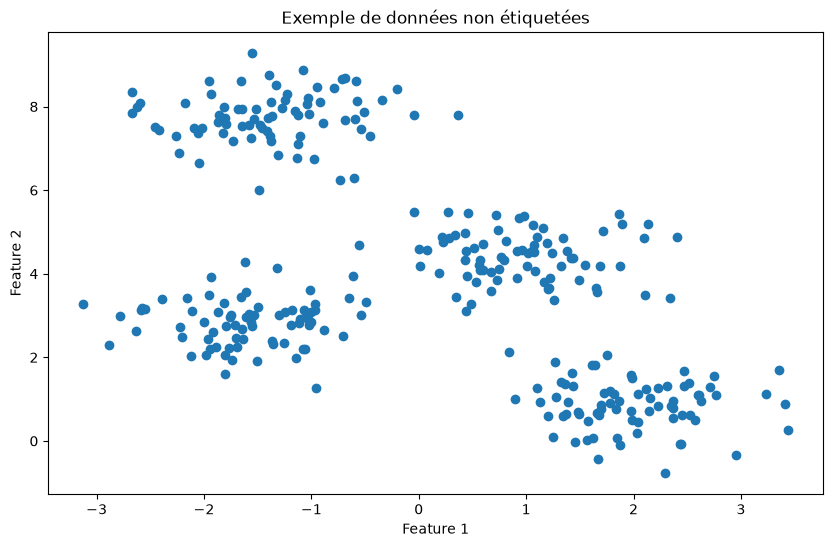

In [4]:
# Visualisation des données
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Exemple de données non étiquetées")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

Exercice 1.1 : 
1. Observer les données ci-dessus
2. Essayer d'identifier visuellement les groupes potentiels
3. Discuter en groupe de ce qui définit un "cluster"

## 1.2 Premier algorithme : K-means

In [5]:
# Exemple basique de K-means
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X)

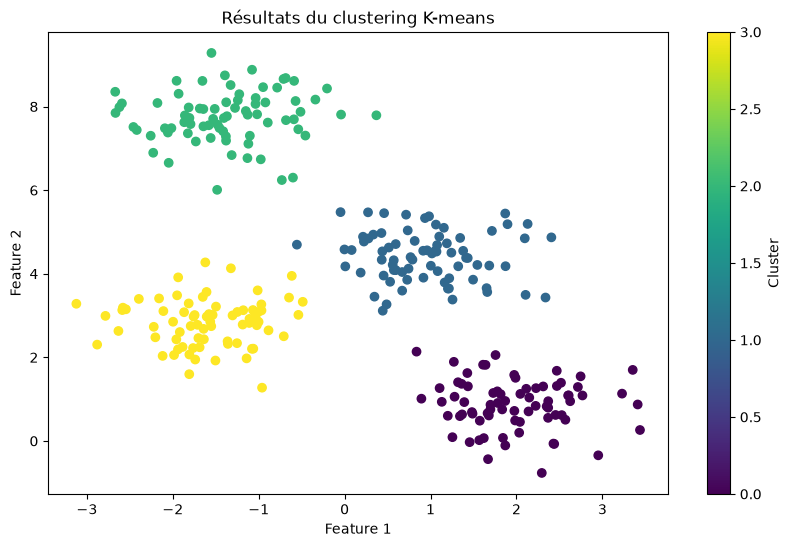

In [6]:
# Visualisation des résultats
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=clusters, cmap='viridis')
plt.title("Résultats du clustering K-means")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster')

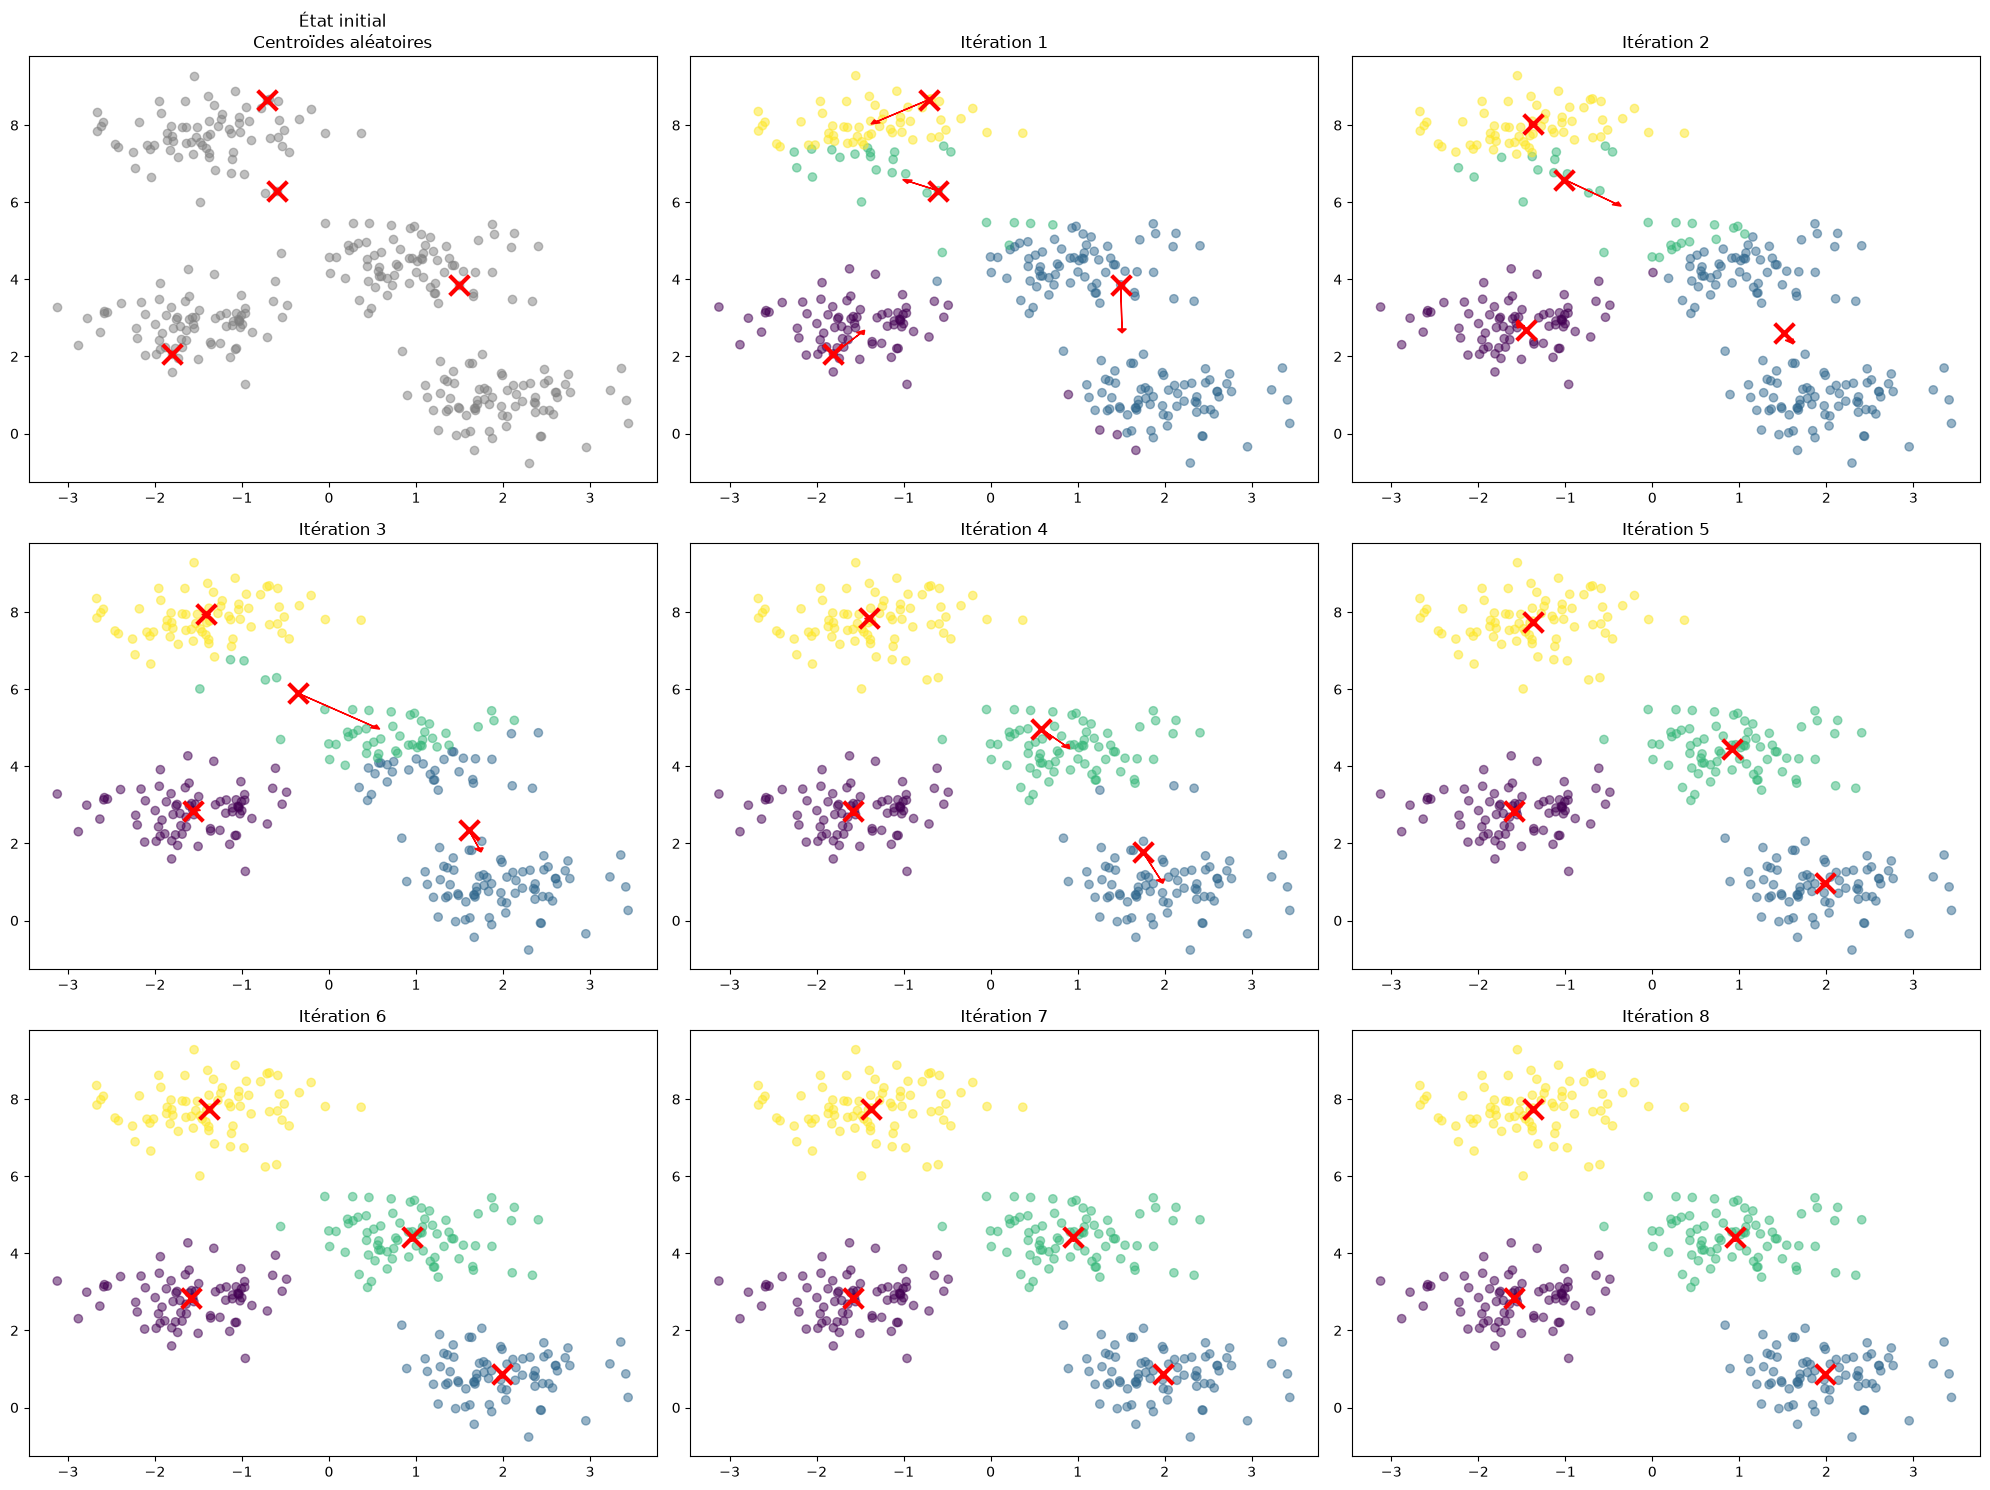

In [7]:
# Fonction pour visualiser les étapes de convergence de K-means
def visualize_kmeans_steps(X, n_clusters=4, max_iter=8):
    # Initialisation des centroides
    np.random.seed(42)
    n_samples, n_features = X.shape
    centers = X[np.random.choice(n_samples, n_clusters, replace=False)]
    labels = np.zeros(n_samples)
    
    plt.figure(figsize=(20, 15))
    
    # Visualisation de l'état initial
    plt.subplot(3, 3, 1)
    plt.scatter(X[:, 0], X[:, 1], c='gray', alpha=0.5)
    plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3)
    plt.title("État initial\nCentroïdes aléatoires")
    
    for iter in range(max_iter):
        # Assignation des points au centroide le plus proche
        for i in range(n_samples):
            dist = np.sqrt(((X[i] - centers) ** 2).sum(axis=1))
            labels[i] = np.argmin(dist)
        
        # Mise à jour des centroides
        new_centers = np.array([X[labels == k].mean(axis=0) for k in range(n_clusters)])
        
        # Visualisation de l'étape
        plt.subplot(3, 3, iter + 2)
        plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.5)
        plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3)
        
        # Tracer les flèches montrant le déplacement des centroides
        for j in range(n_clusters):
            plt.arrow(centers[j, 0], centers[j, 1],
                     new_centers[j, 0] - centers[j, 0],
                     new_centers[j, 1] - centers[j, 1],
                     color='red', head_width=0.1, head_length=0.1, length_includes_head=True)
        
        centers = new_centers.copy()
        plt.title(f"Itération {iter + 1}")
    
    plt.tight_layout()
    plt.show()

# Générer des données pour la démonstration
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Visualiser la convergence
visualize_kmeans_steps(X)

Explication de la convergence :
-----------------------------
1. État initial : 
   - Les centroïdes (×) sont placés aléatoirement
   - Les points ne sont pas encore assignés

2. Premières itérations :
   - Les points sont assignés au centroïde le plus proche (couleurs)
   - Les flèches rouges montrent le déplacement des centroïdes
   - Mouvements importants des centroïdes

3. Itérations suivantes :
   - Les assignations deviennent plus stables
   - Les déplacements des centroïdes diminuent
   - Les clusters commencent à se former clairement

4. Convergence :
   - Les centroïdes se stabilisent
   - Les assignations ne changent plus
   - Les clusters sont bien définis

Points clés :
- La convergence est généralement rapide (4-10 itérations)
- L'initialisation des centroïdes influence le résultat final
- Les flèches montrent la "force" d'attraction des points sur les centroïdes

Exercice 1.2 :
1. Modifier le nombre de clusters (n_clusters)
2. Observer l'impact sur les résultats
3. Discuter : Comment choisir le bon nombre de clusters ?

## 1.3 Prétraitement des données

Importance du prétraitement des données
------------------------------------
Le prétraitement est une étape cruciale en clustering pour plusieurs raisons :

1. Mise à l'échelle :
   - Les algorithmes de clustering sont sensibles aux échelles des variables
   - Des variables à grandes échelles peuvent dominer le calcul des distances
   - La normalisation permet une contribution équitable de chaque variable

2. Gestion des valeurs manquantes :
   - Peut biaiser les résultats du clustering
   - Différentes stratégies : suppression, imputation, etc.

3. Réduction de dimensionnalité :
   - Lutte contre le fléau de la dimensionnalité
   - Améliore la performance des algorithmes
   - Facilite la visualisation

4. Détection et traitement des outliers :
   - Impact fort sur certains algorithmes (K-means)
   - Peut créer des clusters artificiels

In [8]:
# Exemple avec des données non normalisées
X_non_normalized = np.random.random((300, 2)) * [10, 1]

Text(0.5, 1.0, 'Données avant normalisation')

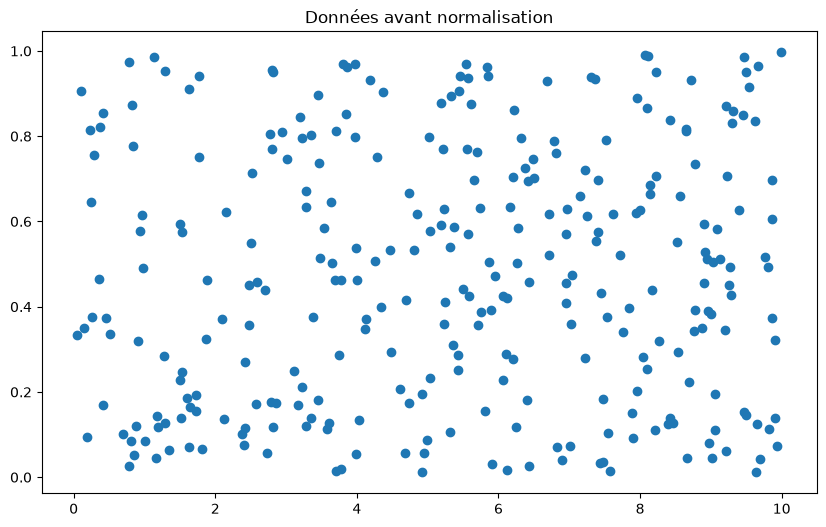

In [9]:
# Visualisation avant normalisation
plt.figure(figsize=(10, 6))
plt.scatter(X_non_normalized[:, 0], X_non_normalized[:, 1])
plt.title("Données avant normalisation")

Text(0.5, 1.0, 'Données avant normalisation')

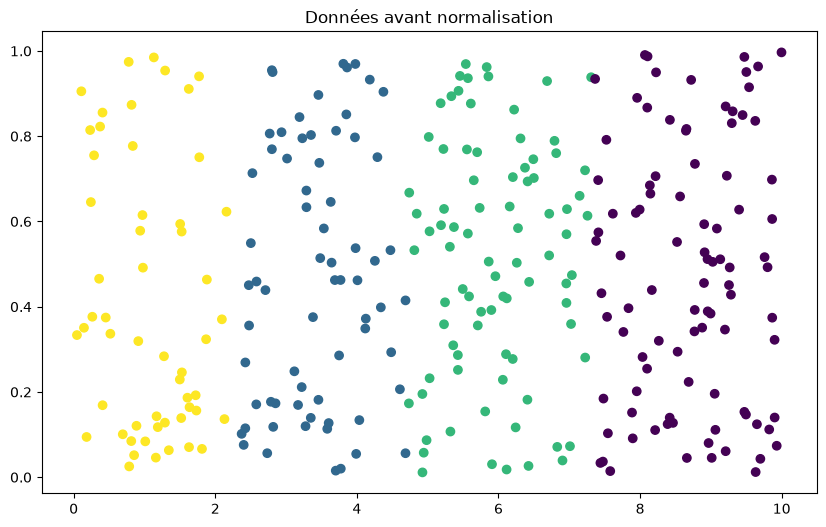

In [10]:
# Visualisation avant normalisation
kmeansnotnormalized = KMeans(n_clusters=4)
clustersnotnorm = kmeansnotnormalized.fit_predict(X_non_normalized)

plt.figure(figsize=(10, 6))
plt.scatter(X_non_normalized[:, 0], X_non_normalized[:, 1],c=clustersnotnorm)
plt.title("Données avant normalisation")

In [11]:
# Normalisation
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_non_normalized)

Text(0.5, 1.0, 'Données après normalisation')

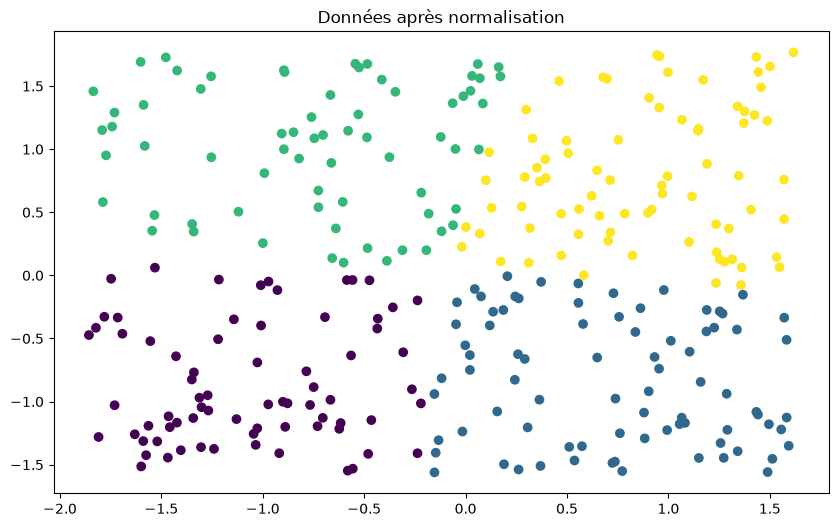

In [12]:
kmeansnormalized = KMeans(n_clusters=4)
clustersnorm = kmeansnormalized.fit_predict(X_normalized)

# Visualisation après normalisation
plt.figure(figsize=(10, 6))
plt.scatter(X_normalized[:, 0], X_normalized[:, 1],c=clustersnorm)
plt.title("Données après normalisation")

Exercice 1.3 :
1. Appliquer K-means sur les données non normalisées
2. Appliquer K-means sur les données normalisées
3. Comparer les résultats

## 2.1 Méthodes d'évaluation

In [13]:
# Génération d'un jeu de données synthétique
np.random.seed(42)
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

### 2.1.1 Méthode du coude


1. Méthode du Coude:


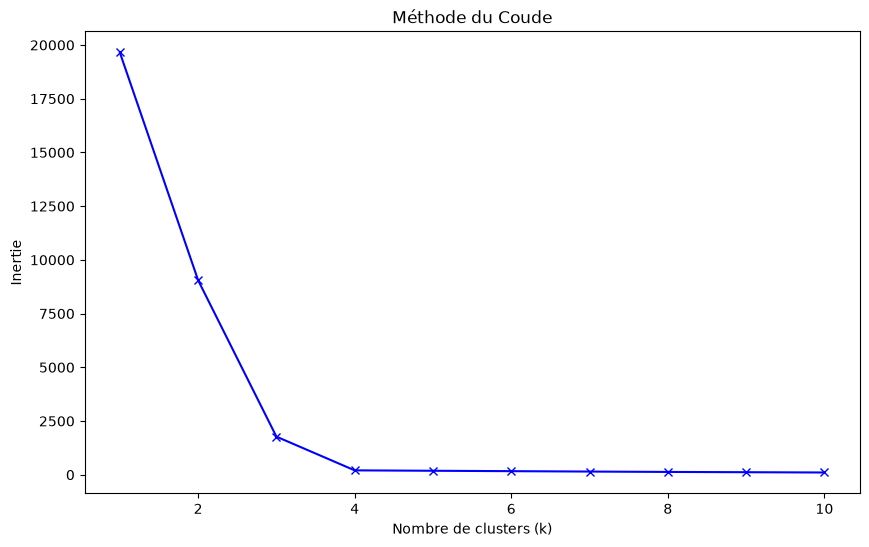


Taux de décroissance de l'inertie entre les clusters successifs:
De 1 à 2 clusters: 53.94%
De 2 à 3 clusters: 80.40%
De 3 à 4 clusters: 88.51%
De 4 à 5 clusters: 9.16%
De 5 à 6 clusters: 9.98%
De 6 à 7 clusters: 11.08%
De 7 à 8 clusters: 11.71%
De 8 à 9 clusters: 9.91%
De 9 à 10 clusters: 11.35%


In [14]:
# 1. Méthode du Coude (Elbow Method)
def plot_elbow_method(X, max_k=10):
    inertias = []
    K = range(1, max_k+1)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
    
    # Visualisation basique
    plt.figure(figsize=(10, 6))
    plt.plot(K, inertias, 'bx-')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Inertie')
    plt.title('Méthode du Coude')
    
    plt.show()

    # Calcul du taux de décroissance
    if len(inertias) > 1:
        decreases = np.diff(inertias) / np.array(inertias)[:-1] * 100
        print("\nTaux de décroissance de l'inertie entre les clusters successifs:")
        for k, decrease in enumerate(decreases, 1):
            print(f"De {k} à {k+1} clusters: {abs(decrease):.2f}%")

# 1. Méthode du Coude
print("\n1. Méthode du Coude:")
plot_elbow_method(X)

La méthode du coude est l'une des approches les plus intuitives pour déterminer le nombre optimal de clusters.

### Principe
- Pour chaque nombre de clusters k, on calcule l'inertie (somme des carrés des distances entre chaque point et le centre de son cluster)
- Plus on ajoute de clusters, plus l'inertie diminue
- L'objectif est de trouver un "coude" dans la courbe, point où ajouter plus de clusters n'apporte plus beaucoup d'amélioration

### Formule de l'inertie pour K-Means

L'inertie dans le cadre d'un algorithme K-Means est définie comme la somme des distances quadratiques entre les points et leurs centroïdes respectifs :

$$
\text{Inertie} = \sum_{i=1}^{k} \sum_{x \in C_i} \| x - \mu_i \|^2
$$

où :

- \( k \) est le nombre de clusters,
- \($ C_i $\) est l'ensemble des points appartenant au cluster \( i \),
- \($ \mu_i $\) est le centroïde du cluster \( i \),
- \($\| x - \mu_i \|^2 $\) est la distance euclidienne au carré entre un point \( x \) et le centroïde \($ \mu_i$ \).

Cette formule mesure la compacité des clusters : plus l'inertie est faible, plus les clusters sont compacts.


### Interprétation
- Le "coude" représente le point où l'ajout de clusters supplémentaires ne réduit plus significativement l'inertie
- C'est un compromis entre la complexité du modèle (nombre de clusters) et sa performance
- La diminution du taux de décroissance de l'inertie aide à identifier ce point

### Forces et faiblesses
- ✅ Simple à comprendre et à visualiser
- ✅ Ne nécessite pas de calculs complexes
- ❌ L'identification du coude peut être subjective
- ❌ Peut être peu claire si les données n'ont pas une structure de cluster naturelle

### 2.1.2 Score silhouette


2. Analyse du Score Silhouette:


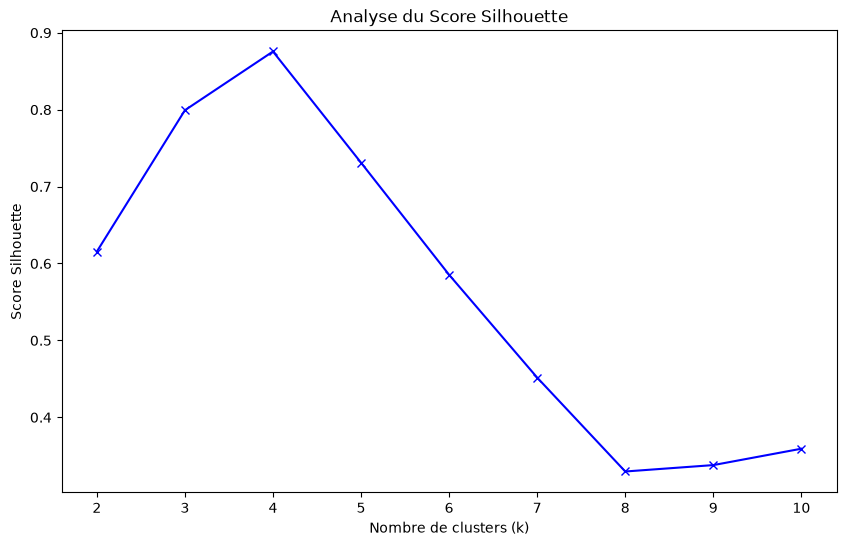

Le meilleur k selon le score Silhouette est: 4
Score Silhouette correspondant: 0.876


In [15]:
# 2. Score Silhouette
def analyze_silhouette(X, max_k=10):
    silhouette_scores = []
    K = range(2, max_k+1)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
    
    plt.figure(figsize=(10, 6))
    plt.plot(K, silhouette_scores, 'bx-')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Score Silhouette')
    plt.title('Analyse du Score Silhouette')
    plt.show()
    
    best_k = K[np.argmax(silhouette_scores)]
    print(f"Le meilleur k selon le score Silhouette est: {best_k}")
    print(f"Score Silhouette correspondant: {max(silhouette_scores):.3f}")

print("\n2. Analyse du Score Silhouette:")
analyze_silhouette(X)

Le score silhouette mesure la qualité de la séparation entre les clusters en comparant la cohésion d'un point avec son propre cluster et la séparation entre ce point et les clusters voisins.

### Principe
Pour chaque point, on calcule :
1. a(i) : distance moyenne avec tous les autres points de son cluster
2. b(i) : distance moyenne minimale avec les points des autres clusters
3. Score silhouette = (b(i) - a(i)) / max(a(i), b(i))

### Interprétation
- Score entre -1 et 1
- Proche de 1 : point bien classé
- Proche de 0 : point à la frontière entre clusters
- Proche de -1 : point probablement mal classé
- Le score global est la moyenne des scores individuels

### Forces et faiblesses
- ✅ Mesure à la fois la cohésion et la séparation
- ✅ Score normalisé facile à interpréter
- ❌ Calcul plus complexe que l'inertie
- ❌ Peut être lent sur de grands jeux de données

## 2.1.3 Score Calinski-Harabasz


3. Analyse du Score Calinski-Harabasz:


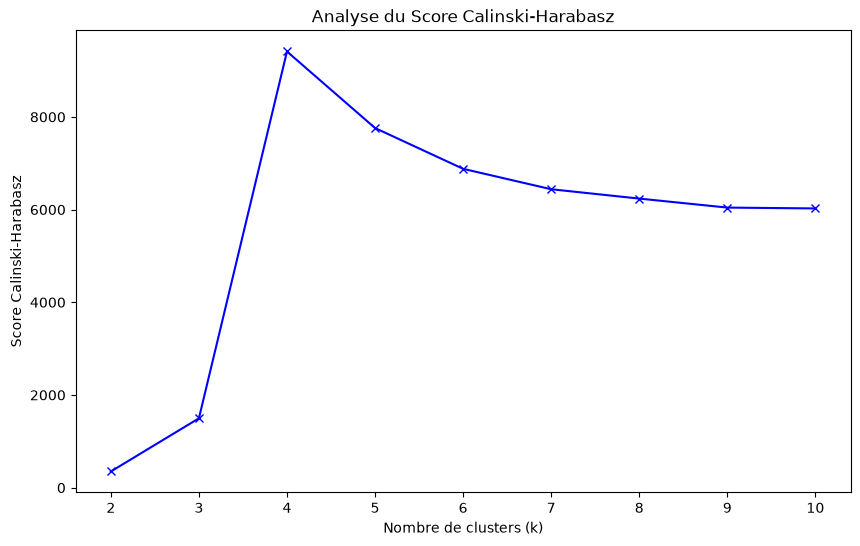

Le meilleur k selon le score Calinski-Harabasz est: 4
Score Calinski-Harabasz correspondant: 9411.507


In [16]:
# 3. Score Calinski-Harabasz
def analyze_calinski_harabasz(X, max_k=10):
    ch_scores = []
    K = range(2, max_k+1)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = calinski_harabasz_score(X, labels)
        ch_scores.append(score)
    
    plt.figure(figsize=(10, 6))
    plt.plot(K, ch_scores, 'bx-')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Score Calinski-Harabasz')
    plt.title('Analyse du Score Calinski-Harabasz')
    plt.show()
    
    best_k = K[np.argmax(ch_scores)]
    print(f"Le meilleur k selon le score Calinski-Harabasz est: {best_k}")
    print(f"Score Calinski-Harabasz correspondant: {max(ch_scores):.3f}")

print("\n3. Analyse du Score Calinski-Harabasz:")
analyze_calinski_harabasz(X)

Le score CH, aussi appelé critère du ratio de variance, compare la dispersion intra-cluster à la dispersion inter-clusters.

### Principe
- Mesure le ratio entre :
  - La moyenne des distances entre clusters (séparation)
  - La moyenne des distances à l'intérieur des clusters (cohésion)
- Multiplié par un facteur de correction basé sur le nombre de clusters et d'échantillons

### Interprétation
- Plus le score est élevé, meilleur est le clustering
- Pas de limite supérieure au score
- Compare la variance entre et au sein des clusters

### Forces et faiblesses
- ✅ Prend en compte à la fois la cohésion et la séparation
- ✅ Rapide à calculer
- ❌ Favorise les clusters convexes
- ❌ Peut être difficile à interpréter car non borné


## 2.1.4 Score Davies-Bouldin


4. Analyse du Score Davies-Bouldin:


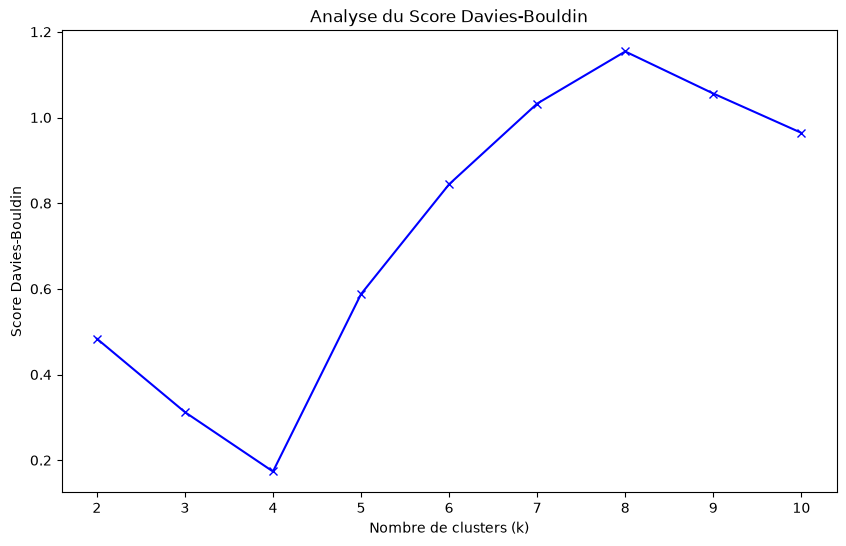

Le meilleur k selon le score Davies-Bouldin est: 4
Score Davies-Bouldin correspondant: 0.174


In [17]:
# 4. Score Davies-Bouldin
def analyze_davies_bouldin(X, max_k=10):
    db_scores = []
    K = range(2, max_k+1)
    
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = davies_bouldin_score(X, labels)
        db_scores.append(score)
    
    plt.figure(figsize=(10, 6))
    plt.plot(K, db_scores, 'bx-')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel('Score Davies-Bouldin')
    plt.title('Analyse du Score Davies-Bouldin')
    plt.show()
    
    best_k = K[np.argmin(db_scores)]
    print(f"Le meilleur k selon le score Davies-Bouldin est: {best_k}")
    print(f"Score Davies-Bouldin correspondant: {min(db_scores):.3f}")

# 4. Score Davies-Bouldin
print("\n4. Analyse du Score Davies-Bouldin:")
analyze_davies_bouldin(X)

Le score DB évalue la similarité moyenne entre chaque cluster et son cluster le plus similaire.

### Principe
1. Pour chaque cluster, on calcule :
   - Sa dispersion interne
   - Sa séparation avec les autres clusters
2. On prend le ratio dispersion/séparation le plus élevé pour chaque paire de clusters
3. On fait la moyenne de ces ratios

### Interprétation
- Plus le score est bas, meilleur est le clustering
- Mesure la séparation moyenne entre clusters
- Prend en compte le pire cas pour chaque cluster

### Forces et faiblesses
- ✅ Prend en compte la dispersion interne et la séparation
- ✅ Ne dépend pas du nombre de clusters
- ❌ Sensible aux valeurs aberrantes
- ❌ Peut être biaisé par des clusters de tailles très différentes

--------------------------------------------

## Conseils d'utilisation

### Quelle métrique choisir ?
1. Pour une première analyse : Méthode du coude
2. Pour une validation approfondie : Score silhouette
3. Pour des clusters bien séparés : Calinski-Harabasz
4. Pour vérifier la robustesse : Davies-Bouldin

### Bonnes pratiques
- Utiliser plusieurs métriques complémentaires
- Tenir compte du contexte métier
- Visualiser les données quand c'est possible
- Ne pas se fier uniquement aux scores numériques

Exercice 2.1 :
1. Interpréter les graphiques
2. Déterminer le nombre optimal de clusters

## 2.2 Clustering hiérarchique

In [18]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [19]:
# Création d'un clustering hiérarchique
hierarchical = AgglomerativeClustering(n_clusters=4)
hier_labels = hierarchical.fit_predict(X)


Text(0, 0.5, 'Distance')

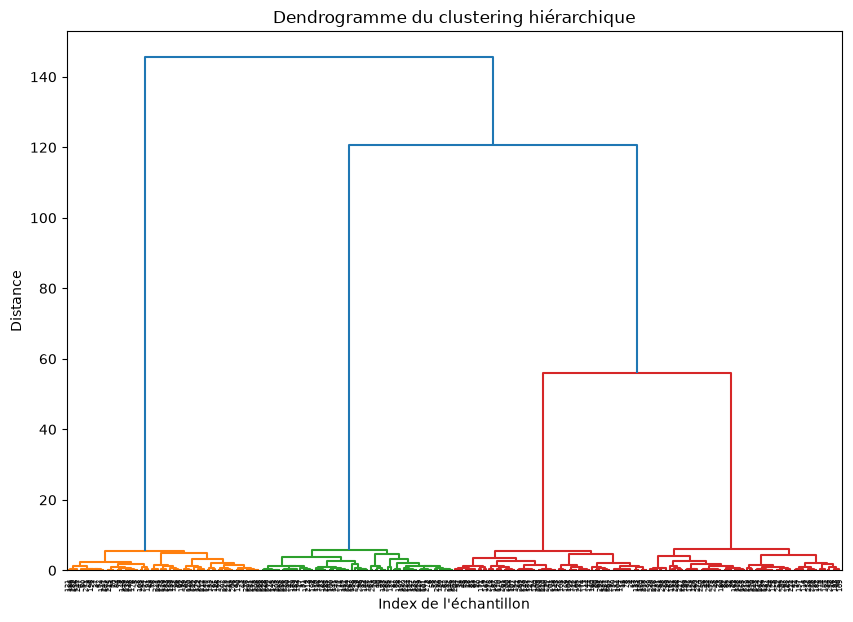

In [20]:
# Visualisation du dendrogramme
linkage_matrix = linkage(X, 'ward')
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title('Dendrogramme du clustering hiérarchique')
plt.xlabel('Index de l\'échantillon')
plt.ylabel('Distance')


Exercice 2.2 :
1. Modifier le nombre de clusters
2. Tester différentes méthodes de liaison (ward, complete, average)
3. Analyser le dendrogramme

## 3.1 DBSCAN

In [39]:
# Création de données en forme de croissant
X_moons, _ = make_moons(n_samples=200, noise=0.05, random_state=42)

In [40]:
bad_kmeans = KMeans(n_clusters=2)
bad_kmeans_label = bad_kmeans.fit_predict(X_moons)

C:\Users\e.vervaeren\AppData\Local\Temp\ipykernel_14124\1897348894.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_moons[:, 0], X_moons[:, 1], cmap='viridis')


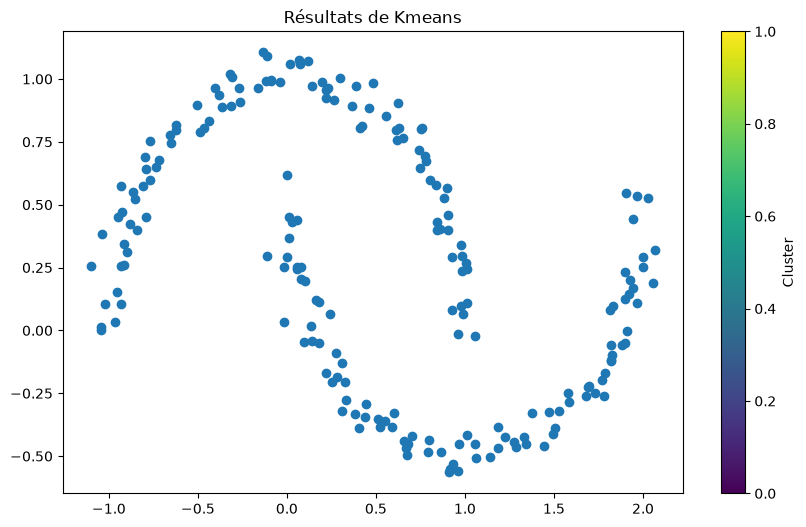

In [41]:
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], cmap='viridis')
plt.title("Résultats de Kmeans")
plt.colorbar(label='Cluster')

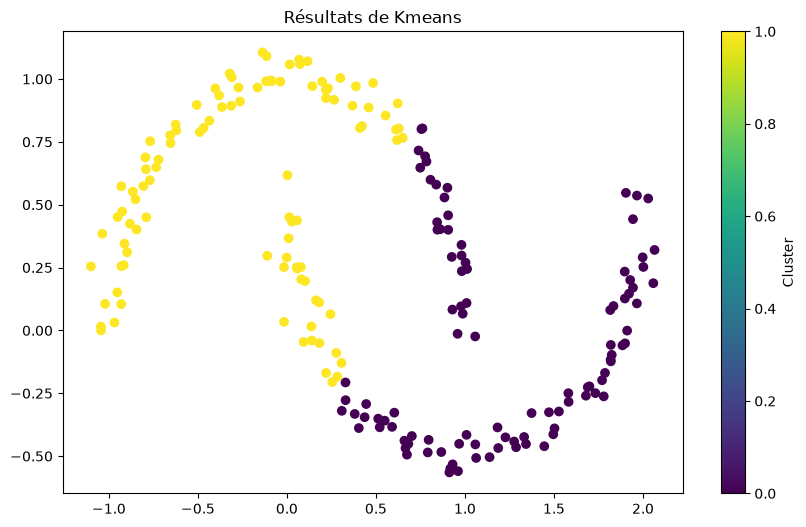

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=bad_kmeans_label, cmap='viridis')
plt.title("Résultats de Kmeans")
plt.colorbar(label='Cluster')

In [44]:
# Application de DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_moons)

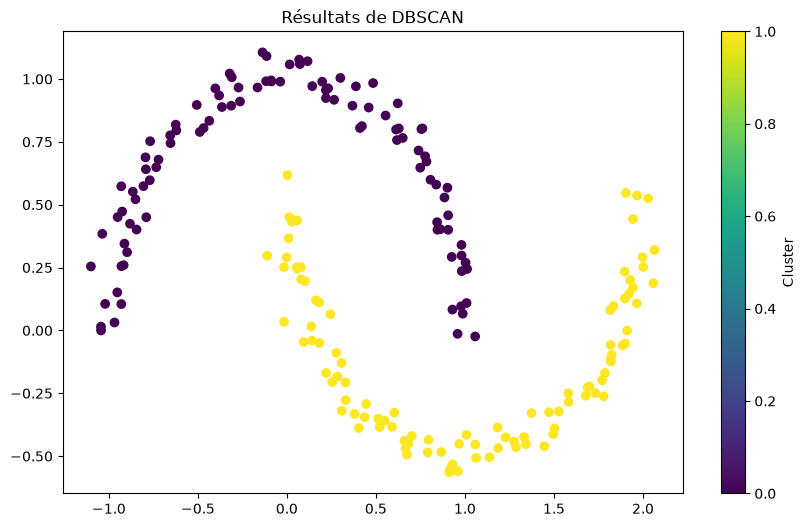

In [45]:
# Visualisation
plt.figure(figsize=(10, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=dbscan_labels, cmap='viridis')
plt.title("Résultats de DBSCAN")
plt.colorbar(label='Cluster')

Exercice 3.1 :
1. Modifier les paramètres eps et min_samples
2. Observer l'impact sur les résultats
3. Identifier les points de bruit (noise)

## 3.2 Comparaison des algorithmes

In [27]:
# Création de différents types de données
datasets = {
    "blobs": make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)[0],
    "moons": make_moons(n_samples=200, noise=0.05, random_state=42)[0],
    "circles": make_moons(n_samples=200, noise=0.05, random_state=42)[0]  # Pour l'exemple
}

In [28]:
# Application des différents algorithmes
algorithms = {
    "KMeans": KMeans(n_clusters=4),
    "DBSCAN": DBSCAN(eps=0.3, min_samples=5),
    "Hierarchical": AgglomerativeClustering(n_clusters=4)
}

Exercice 3.2 :
1. Appliquer chaque algorithme sur chaque jeu de données
2. Comparer les résultats visuellement
3. Discuter des forces et faiblesses de chaque algorithme

## 3.3 Clustering Spectral

Théorie du Clustering Spectral
----------------------------
Le clustering spectral est une technique sophistiquée qui utilise les vecteurs propres de la matrice 
de similarité des données pour réduire la dimensionnalité avant d'effectuer le clustering.

Principe fondamental :
1. Construction d'un graphe de similarité entre les points
2. Calcul de la matrice laplacienne du graphe
3. Décomposition spectrale (calcul des vecteurs propres)
4. Clustering dans l'espace des vecteurs propres

Avantages théoriques :
- Peut identifier des clusters de forme complexe
- Base mathématique solide (théorie spectrale des graphes)
- Efficace pour les structures non linéairement séparables

Types de matrices laplaciennes :

1. Laplacienne non normalisée : 
$$ L = D - W $$

2. Laplacienne normalisée symétrique : 
$$ L_{sym} = I - D^{-\frac{1}{2}}WD^{-\frac{1}{2}} $$

3. Laplacienne normalisée marche aléatoire : 
$$ L_{rw} = I - D^{-1}W $$

Où :
- $W$ est la matrice d'adjacence (similarités)
- $D$ est la matrice diagonale des degrés
- $I$ est la matrice identité

In [29]:
# Création de données en forme de cercles concentriques
def make_circles_data():
    n_samples = 1000
    
    # Premier cercle
    t = np.random.uniform(0, 2*np.pi, n_samples//2)
    r1 = 0.3 + np.random.normal(0, 0.02, n_samples//2)
    x1 = r1 * np.cos(t)
    y1 = r1 * np.sin(t)
    
    # Second cercle
    t = np.random.uniform(0, 2*np.pi, n_samples//2)
    r2 = 0.8 + np.random.normal(0, 0.02, n_samples//2)
    x2 = r2 * np.cos(t)
    y2 = r2 * np.sin(t)
    
    X = np.vstack([np.column_stack((x1, y1)), np.column_stack((x2, y2))])
    return X

Text(0.5, 1.0, 'Données originales')

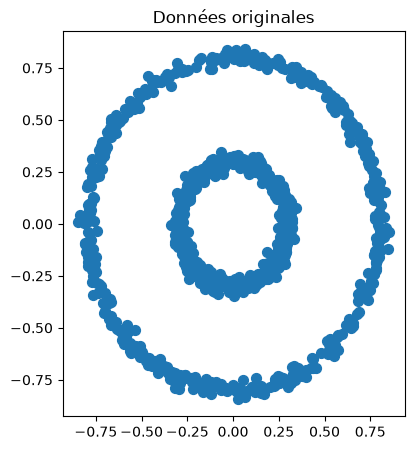

In [30]:
# Génération des données
X = make_circles_data()

# Visualisation des données originales
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Données originales")

Étapes de la transformation spectrale
----------------------------------
1. Construction de la matrice de similarité
2. Calcul des vecteurs propres
3. Projection des données
4. Application de K-means

c:\Users\e.vervaeren\Desktop\Learning-IOT-AI-Architect\Python\pyhton_data_science\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


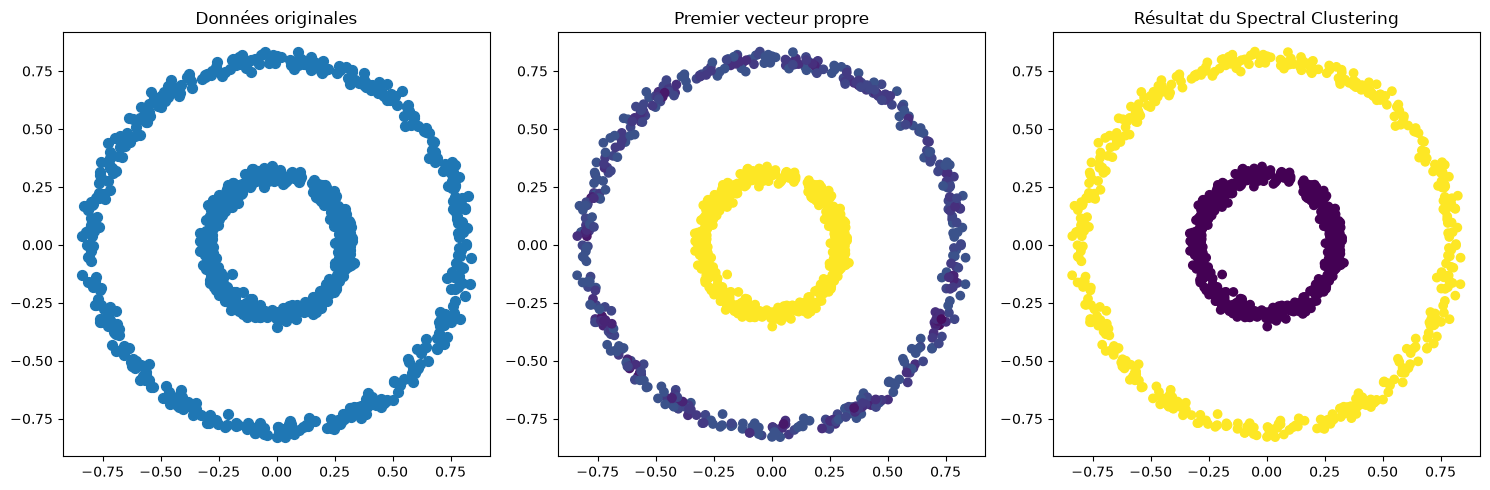

In [31]:
# Création de données en forme de cercles concentriques
def make_circles_data():
    n_samples = 1000
    
    # Premier cercle
    t = np.random.uniform(0, 2*np.pi, n_samples//2)
    r1 = 0.3 + np.random.normal(0, 0.02, n_samples//2)
    x1 = r1 * np.cos(t)
    y1 = r1 * np.sin(t)
    
    # Second cercle
    t = np.random.uniform(0, 2*np.pi, n_samples//2)
    r2 = 0.8 + np.random.normal(0, 0.02, n_samples//2)
    x2 = r2 * np.cos(t)
    y2 = r2 * np.sin(t)
    
    X = np.vstack([np.column_stack((x1, y1)), np.column_stack((x2, y2))])
    return X

# Génération des données
X = make_circles_data()

# Visualisation des données originales
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Données originales")

# Construction de la matrice d'adjacence
adjacency = kneighbors_graph(X, n_neighbors=10, mode='distance', include_self=True)
adjacency = 0.5 * (adjacency + adjacency.T)
adjacency.data = np.exp(-adjacency.data**2 / (2.))
adjacency = adjacency.toarray()

# Calcul de la matrice laplacienne normalisée
diag = np.sum(adjacency, axis=1)
D = np.diag(diag)
L = D - adjacency

# Calcul de la matrice D^(-1/2)
D_sqrt_inv = np.diag(1.0 / np.sqrt(diag + 1e-10))  # Ajout d'un petit epsilon pour éviter la division par zéro

# Calcul de la laplacienne normalisée
L_norm = D_sqrt_inv @ L @ D_sqrt_inv

# Calcul des vecteurs propres
n_clusters = 2
eigenvalues, eigenvectors = np.linalg.eigh(L_norm)
# On prend les k plus petites valeurs propres (en excluant la plus petite qui est proche de 0)
indices = np.argsort(eigenvalues)[1:n_clusters+1]
embeddings = eigenvectors[:, indices]

# Visualisation des vecteurs propres
plt.subplot(132)
plt.scatter(X[:, 0], X[:, 1], c=embeddings[:, 0], cmap='viridis')
plt.title("Premier vecteur propre")

# Application du Spectral Clustering avec scikit-learn
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                             n_neighbors=10, random_state=42)
labels = spectral.fit_predict(X)

plt.subplot(133)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Résultat du Spectral Clustering")
plt.tight_layout()
plt.show()


Analyse des résultats
-------------------
1. Structure des clusters :
   - Capacité à détecter des formes non linéaires
   - Séparation claire des cercles concentriques
   - Robustesse au bruit

2. Paramètres importants :
   - n_neighbors : nombre de voisins pour la construction du graphe
   - affinity : type de matrice de similarité
   - n_clusters : nombre de clusters souhaités

Comparaison avec d'autres méthodes :
----------------------------------
Forces :
+ Excellent pour les formes complexes et non linéaires
+ Base mathématique solide
+ Moins sensible aux outliers que K-means

Faiblesses :
- Coût calculatoire élevé (O(n³) dans le cas naïf)
- Sensible au choix des paramètres de similarité
- Peut être instable pour de très grands jeux de données

Cas d'utilisation recommandés :
- Clusters de formes complexes
- Données avec structure manifold
- Taille de données moyenne (< 10000 points)

c:\Users\e.vervaeren\Desktop\Learning-IOT-AI-Architect\Python\pyhton_data_science\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


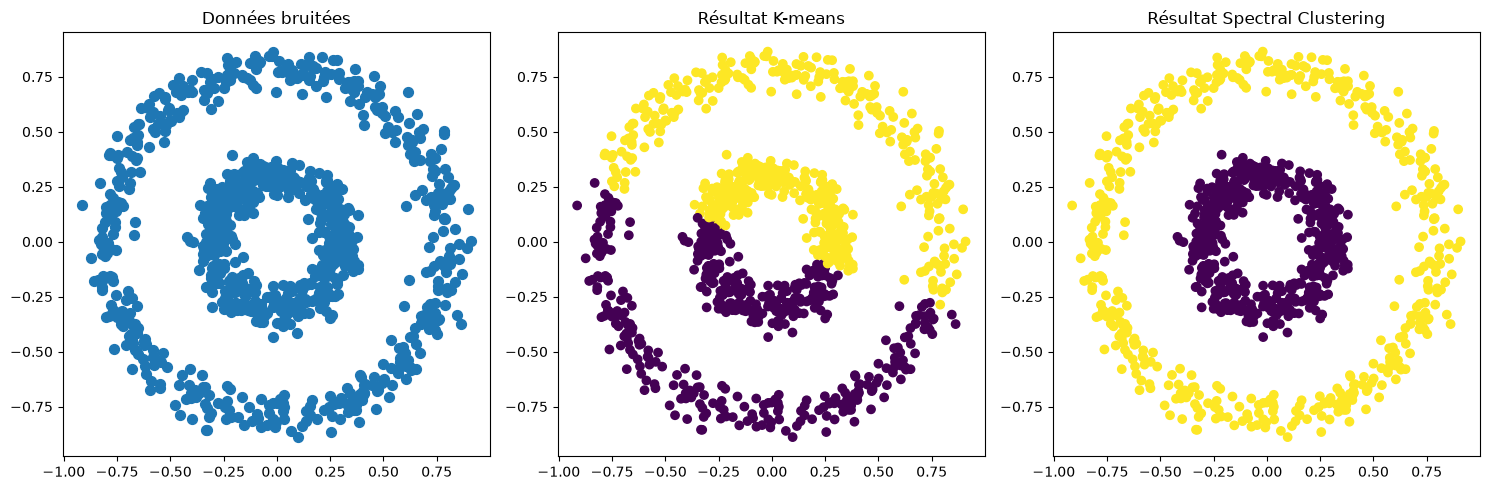

In [32]:
# Démonstration de la robustesse du Spectral Clustering
def compare_clustering_methods(X, noise_level=0.1):
    # Ajout de bruit
    X_noisy = X + np.random.normal(0, noise_level, X.shape)
    
    # K-means
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_noisy)
    
    # Spectral Clustering
    spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                                 n_neighbors=10, random_state=42)
    spectral_labels = spectral.fit_predict(X_noisy)
    
    # Visualisation
    plt.figure(figsize=(15, 5))
    
    plt.subplot(131)
    plt.scatter(X_noisy[:, 0], X_noisy[:, 1], s=50)
    plt.title("Données bruitées")
    
    plt.subplot(132)
    plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=kmeans_labels, cmap='viridis')
    plt.title("Résultat K-means")
    
    plt.subplot(133)
    plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=spectral_labels, cmap='viridis')
    plt.title("Résultat Spectral Clustering")
    
    plt.tight_layout()
    plt.show()

# Démonstration avec différents niveaux de bruit
compare_clustering_methods(X, noise_level=0.05)

Exercices pratiques :
-------------------
1. Modifier les paramètres du Spectral Clustering :
   - Tester différents nombres de voisins
   - Essayer différentes matrices d'affinité
   - Observer l'impact sur les résultats

2. Comparer les performances :
   - Tester sur différentes formes de clusters
   - Mesurer le temps d'exécution
   - Évaluer la robustesse au bruit

3. Application réelle :
   - Choisir un dataset réel
   - Appliquer le Spectral Clustering
   - Comparer avec K-means et DBSCAN

## 4.1 Cas d'étude : Segmentation de clients

In [33]:
# Chargement d'un exemple de données clients
from sklearn.datasets import make_classification
X_customers, _ = make_classification(n_samples=1000, n_features=5, n_informative=5, n_redundant=0, random_state=42)
customer_data = pd.DataFrame(X_customers, columns=['Recence', 'Frequence', 'Montant', 'Anciennete', 'Age'])

In [34]:
# Préparation des données
scaler = StandardScaler()
X_customers_scaled = scaler.fit_transform(customer_data)

In [35]:
# Application du clustering
kmeans = KMeans(n_clusters=5, random_state=42)
customer_segments = kmeans.fit_predict(X_customers_scaled)

In [36]:
# Analyse des segments
customer_data['Segment'] = customer_segments
segment_analysis = customer_data.groupby('Segment').mean()

Exercice 4.1 :
1. Analyser les caractéristiques de chaque segment
2. Créer des visualisations pertinentes
3. Proposer des stratégies marketing pour chaque segment

## 4.2 Mini-projet final

Projet final :
1. Choisir un dataset réel (ex: données de ventes, données médicales, etc.)
2. Appliquer une démarche complète de clustering :
   - Préparation des données
   - Choix de l'algorithme
   - Optimisation des paramètres
   - Évaluation des résultats
3. Présenter les résultats et les interprétations